In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Initialisierung (in Python nicht zwingend notwendig, aber für Reproduzierbarkeit gut)
np.random.seed(42) 

# Hilfsfunktion, um MATLABs fspecial('gaussian', ...) nachzubilden
def gaussian_kernel(size, sigma=1):
    window = signal.windows.gaussian(size, std=sigma)
    return window / window.sum() # Normalisierung, damit Summe = 1

## a) Signale erstellen

In [2]:
# s1: Rechtecksignal
s1 = np.zeros(30)
s1[10:20] = 1 

# s2: Tiefpassfilterung für weiche Kanten
h_gauss = gaussian_kernel(5, sigma=1)
s2 = np.convolve(s1, h_gauss, mode='same')

# s3: Verrauschtes Signal
s3 = s2 + 0.1 * np.random.randn(30)

## b) Einfaches Gradientenfilter

In [4]:
h_grad = np.array([-1, 1])

# Faltung mit Gradientenfilter
u1 = np.convolve(s1, h_grad, mode='same')
u2 = np.convolve(s2, h_grad, mode='same')
u3 = np.convolve(s3, h_grad, mode='same')

## c) Verbesserung: TP Filterung des Eingangs um Rauschen zu glätten

In [7]:
# h_TP entspricht hier demselben Gaussian Kernel wie oben
h_TP = gaussian_kernel(5, sigma=1)

# Erste Stufe: Glättung (TP)
u11 = np.convolve(s1, h_TP, mode='same')
u21 = np.convolve(s2, h_TP, mode='same')
u31 = np.convolve(s3, h_TP, mode='same')

# Zweite Stufe: Gradient
u12 = np.convolve(u11, h_grad, mode='same')
u22 = np.convolve(u21, h_grad, mode='same')
u32 = np.convolve(u31, h_grad, mode='same')

## Plots

In [11]:
# Funktion zum schnellen Plotten (um Code-Duplizierung zu vermeiden)
def plot_signal_group(title_fig, data_s, data_u_simple, data_u_tp, title_s):
    fig, axs = plt.subplots(3, 1, figsize=(8, 10), constrained_layout=True)
    fig.canvas.manager.set_window_title(title_fig) # Funktioniert in interaktiven Backends
    fig.suptitle(title_fig, fontsize=16)

    # Subplot 1: Das Signal selbst
    axs[0].stem(data_s)
    axs[0].set_xlabel('n')
    axs[0].set_title(title_s)
    axs[0].grid(True, alpha=0.3)

    # Subplot 2: Einfaches Gradientenfilter
    axs[1].stem(data_u_simple)
    axs[1].set_xlabel('n')
    axs[1].set_title('Einfaches Gradientenfilter')
    axs[1].grid(True, alpha=0.3)

    # Subplot 3: TP + Gradientenfilter
    axs[2].stem(data_u_tp)
    axs[2].set_xlabel('n')
    axs[2].set_title('TP + Gradientenfilter')
    axs[2].grid(True, alpha=0.3)
    
    plt.show()

### F1: Steile Signalflanken

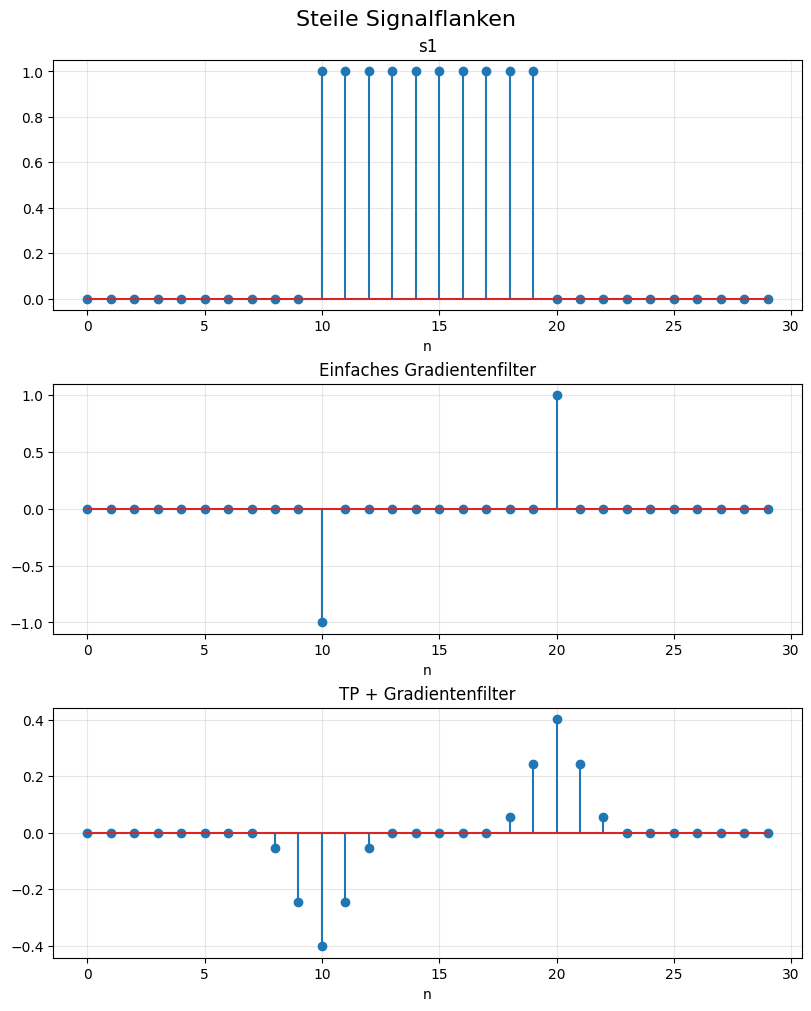

In [12]:
plot_signal_group('Steile Signalflanken', s1, u1, u12, 's1')

### F2: Weiche Signalflanken

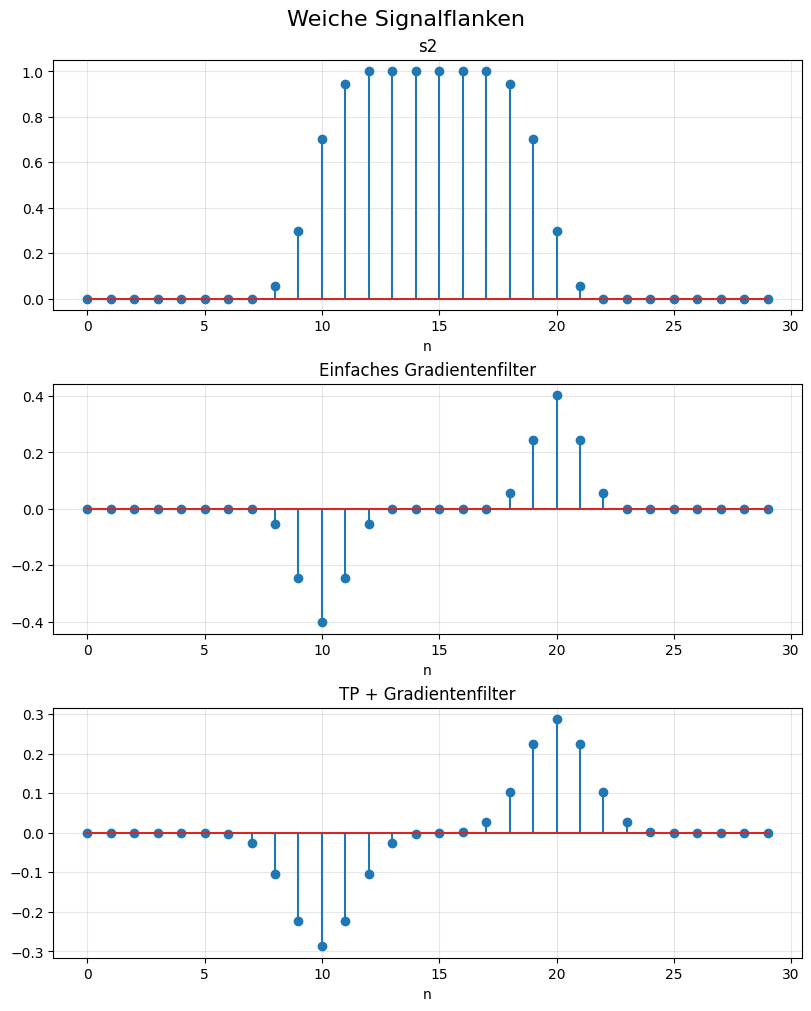

In [13]:
plot_signal_group('Weiche Signalflanken', s2, u2, u22, 's2')

### F3: Weiche Flanken und verrauschtes Signal

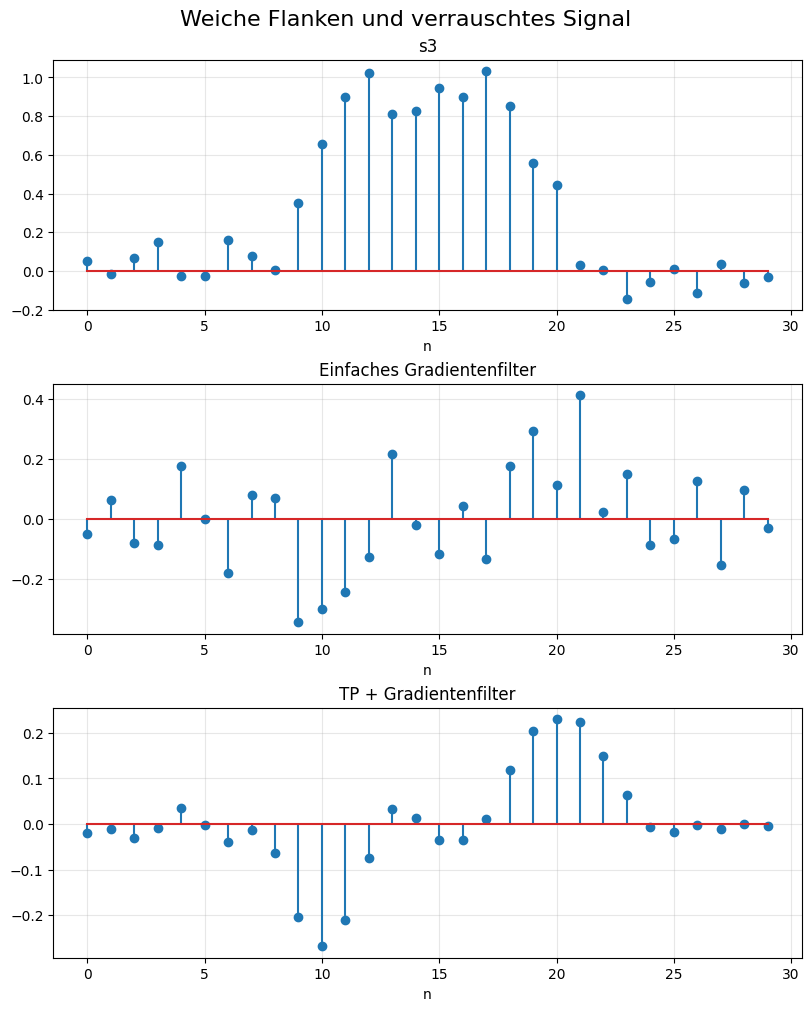

In [14]:
plot_signal_group('Weiche Flanken und verrauschtes Signal', s3, u3, u32, 's3')